<a href="https://colab.research.google.com/github/Areeba-Nizami/ML/blob/Simple-Neural-Network-Development-for-Digit-Classification/%3A%20Simple%20Neural%20Network%20Development%20for%20Digit%20Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

# **1.	Dataset Loading and Preprocessing**

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)

Sample label: 5
Pixel value range: 0 to 255


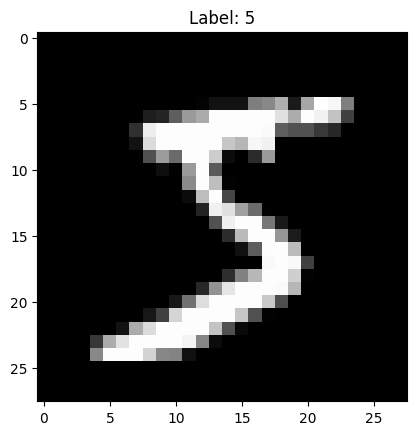

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("\nSample label:", y_train[0])
print("Pixel value range:", X_train.min(), "to", X_train.max())
plt.imshow(X_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

In [3]:
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0
X_train_flat = X_train_norm.reshape(X_train_norm.shape[0], 28*28)
X_test_flat = X_test_norm.reshape(X_test_norm.shape[0], 28*28)

In [4]:
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

X_train_flat = X_train_norm.reshape(X_train_norm.shape[0], 28*28)
X_test_flat = X_test_norm.reshape(X_test_norm.shape[0], 28*28)

y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

print("X_train_flat shape:", X_train_flat.shape)
print("X_test_flat shape:", X_test_flat.shape)
print("y_train_cat shape:", y_train_cat.shape)
print("Sample label before encoding:", y_train[0])
print("Sample label after encoding:", y_train_cat[0])

X_train_flat shape: (60000, 784)
X_test_flat shape: (10000, 784)
y_train_cat shape: (60000, 10)
Sample label before encoding: 5
Sample label after encoding: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


# 2. Neural Network Architecture Design and Training
### Model A: Use the ReLU (Rectified Linear Unit) activation function

In [5]:
model_relu = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_relu.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model_relu.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
history_relu = model_relu.fit(
    X_train_flat, y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9214 - loss: 0.2693 - val_accuracy: 0.9579 - val_loss: 0.1427
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9664 - loss: 0.1122 - val_accuracy: 0.9653 - val_loss: 0.1138
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9758 - loss: 0.0777 - val_accuracy: 0.9684 - val_loss: 0.1071
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9809 - loss: 0.0596 - val_accuracy: 0.9734 - val_loss: 0.0877
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9854 - loss: 0.0447 - val_accuracy: 0.9762 - val_loss: 0.0859
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9883 - loss: 0.0354 - val_accuracy: 0.9731 - val_loss: 0.1053
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9903 - loss: 0.0301 - val_accuracy: 0.9677 - val_loss: 0.1237
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9921 - loss: 0.0238 - 

# Model B: Use the Sigmoid activation function#

In [8]:
model_sigmoid = keras.Sequential([
    layers.Dense(128, activation='sigmoid', input_shape=(784,)),
    layers.Dense(64, activation='sigmoid'),
    layers.Dense(10, activation='softmax')
])

model_sigmoid.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_sigmoid = model_sigmoid.fit(
    X_train_flat, y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8675 - loss: 0.5319 - val_accuracy: 0.9356 - val_loss: 0.2287
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9411 - loss: 0.2005 - val_accuracy: 0.9539 - val_loss: 0.1636
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9583 - loss: 0.1407 - val_accuracy: 0.9618 - val_loss: 0.1319
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9681 - loss: 0.1066 - val_accuracy: 0.9641 - val_loss: 0.1194
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9761 - loss: 0.0827 - val_accuracy: 0.9686 - val_loss: 0.1087
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9810 - loss: 0.0655 - val_accuracy: 0.9688 - val_loss: 0.1036
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9848 - loss: 0.0518 - val_accuracy: 0.9728 - val_loss: 0.0889
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9881 - loss: 0.0406 - 

# 3. Performance Visualization

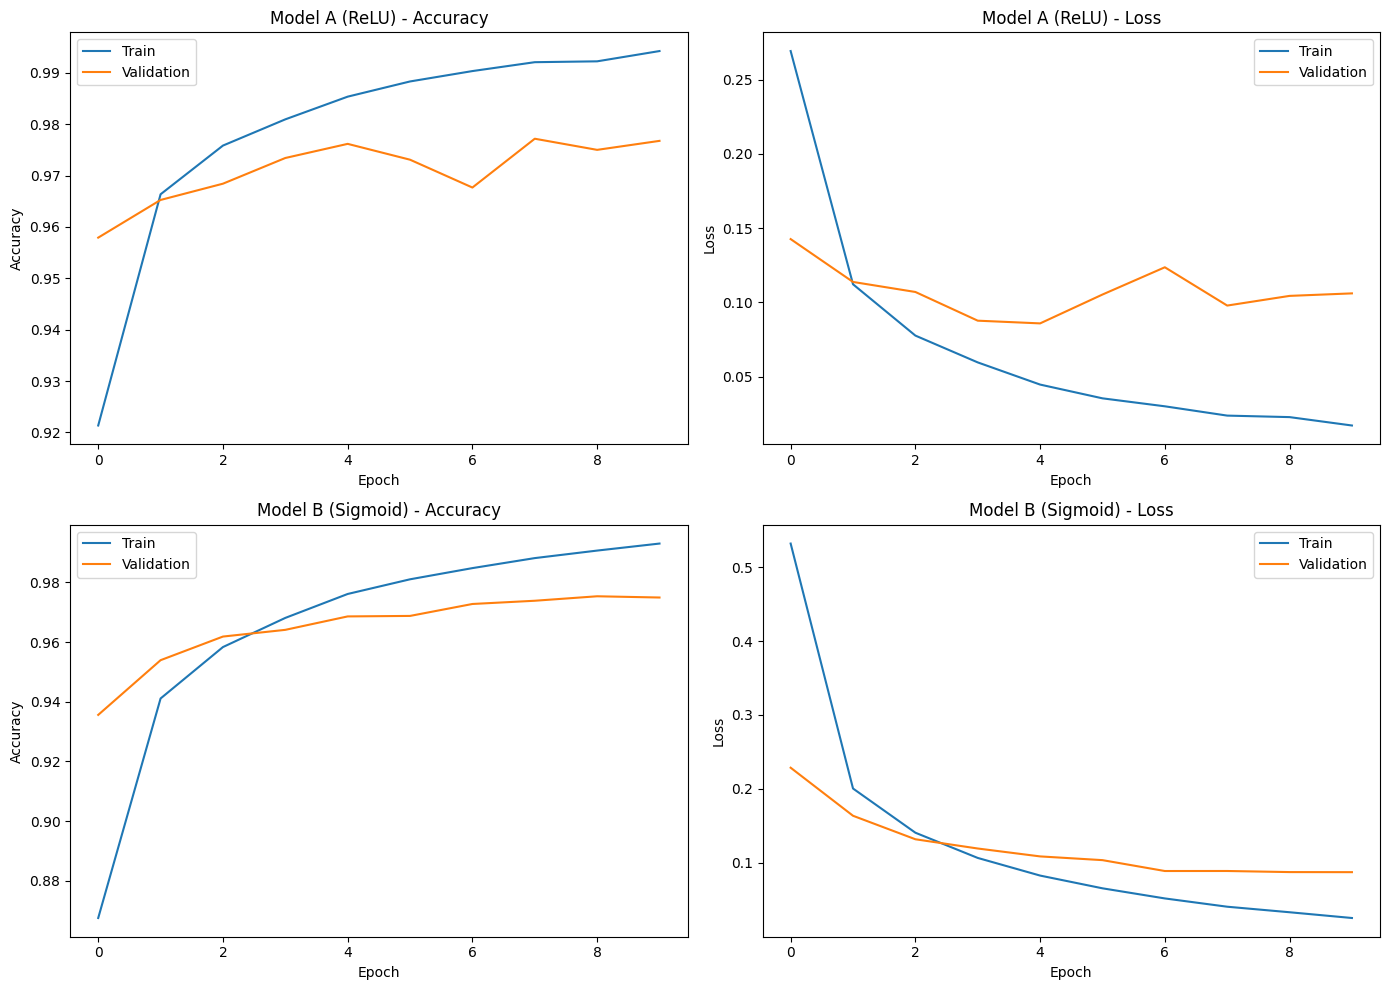

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Model A (ReLU) - Accuracy
axes[0,0].plot(history_relu.history['accuracy'], label='Train')
axes[0,0].plot(history_relu.history['val_accuracy'], label='Validation')
axes[0,0].set_title('Model A (ReLU) - Accuracy')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].legend()

# Model A (ReLU) - Loss
axes[0,1].plot(history_relu.history['loss'], label='Train')
axes[0,1].plot(history_relu.history['val_loss'], label='Validation')
axes[0,1].set_title('Model A (ReLU) - Loss')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Loss')
axes[0,1].legend()

# Model B (Sigmoid) - Accuracy
axes[1,0].plot(history_sigmoid.history['accuracy'], label='Train')
axes[1,0].plot(history_sigmoid.history['val_accuracy'], label='Validation')
axes[1,0].set_title('Model B (Sigmoid) - Accuracy')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Accuracy')
axes[1,0].legend()

# Model B (Sigmoid) - Loss
axes[1,1].plot(history_sigmoid.history['loss'], label='Train')
axes[1,1].plot(history_sigmoid.history['val_loss'], label='Validation')
axes[1,1].set_title('Model B (Sigmoid) - Loss')
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('Loss')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('relu_vs_sigmoid_curves.png', dpi=300)
plt.show()

In [11]:
test_loss_relu, test_acc_relu = model_relu.evaluate(X_test_flat, y_test_cat, verbose=0)
test_loss_sigmoid, test_acc_sigmoid = model_sigmoid.evaluate(X_test_flat, y_test_cat, verbose=0)

print(f"ReLU    - Test Accuracy: {test_acc_relu:.4f}, Test Loss: {test_loss_relu:.4f}")
print(f"Sigmoid - Test Accuracy: {test_acc_sigmoid:.4f}, Test Loss: {test_loss_sigmoid:.4f}")

ReLU    - Test Accuracy: 0.9755, Test Loss: 0.0980
Sigmoid - Test Accuracy: 0.9747, Test Loss: 0.0866


# 4. Comparative Analysis
ReLU vs Sigmoid

Both models were trained using the same architecture (two hidden layers with 128 and 64 neurons) and the same optimizer, loss function, batch size, and number of epochs. The only difference was the activation function used in the hidden layers, which makes this a fair comparison of the two functions themselves.

In terms of convergence speed, ReLU learned faster early on, reaching 92.4 percent training accuracy after just the first epoch compared to sigmoid's 86.7 percent. This matches the theory that sigmoid's gradient becomes very small for large or very negative inputs, which slows down early learning, while ReLU keeps a constant gradient for positive inputs and updates weights more efficiently from the start.

However, by the end of training the picture changes. ReLU's validation accuracy peaked at epoch 8 around 97.5 percent and then dropped slightly to 96.8 percent by epoch 10, while its validation loss actually increased from about 0.086 to 0.144 over the same stretch. This is a clear sign of overfitting, where the model kept improving on the training data while performing worse on data it had not seen. This shows up clearly in the plots as well, where the ReLU loss curve for validation curls upward after around epoch 4 while the training loss keeps falling.

Sigmoid, on the other hand, did not show this pattern within the 10 epochs. Its validation accuracy kept improving until the last epoch, ending at 97.6 percent, and its validation loss kept decreasing the entire time, ending around 0.084, which is close to half of ReLU's final validation loss. The training and validation curves for sigmoid stayed much closer together throughout training, both in the accuracy and loss plots, indicating that the model generalized well and had not started overfitting yet.

This result goes against the common assumption that ReLU is simply the better choice. The likely explanation is that the vanishing gradient problem associated with sigmoid becomes a serious issue mainly in deep networks with many layers, and this network only has two hidden layers, which is shallow enough that sigmoid's weakness did not really come into play. Meanwhile, ReLU's faster convergence, which is usually an advantage, actually became a disadvantage here since it allowed the model to fit the training data very closely and start overfitting sooner.

The overall takeaway is that the choice of activation function cannot be judged in isolation. Its effect depends heavily on the depth and design of the network, and in this particular shallow architecture, sigmoid ended up generalizing better than ReLU even though ReLU is generally considered the modern default for hidden layers.
